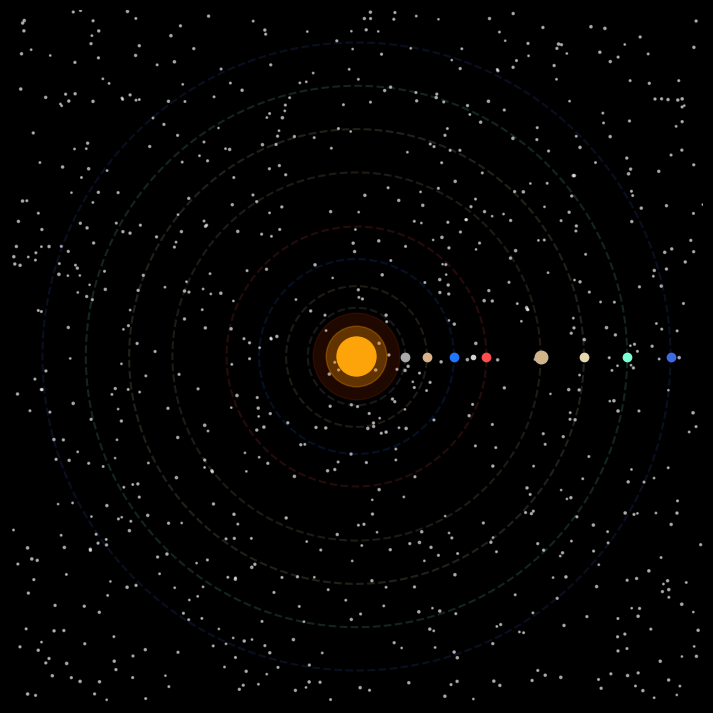

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
ax.set_aspect('equal')
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.axis("off")

# -----------------------------
# Starfield
# -----------------------------
np.random.seed(42)
ax.scatter(
    np.random.uniform(-3.2, 3.2, 800),
    np.random.uniform(-3.2, 3.2, 800),
    s=np.random.uniform(1, 3, 800),
    color="white",
    alpha=0.5
)

# -----------------------------
# Sun (glow effect)
# -----------------------------
ax.add_patch(plt.Circle((0, 0), 0.18, color="#FDB813"))
ax.add_patch(plt.Circle((0, 0), 0.28, color="#FFA500", alpha=0.3))
ax.add_patch(plt.Circle((0, 0), 0.40, color="#FF4500", alpha=0.12))

# -----------------------------
# Planet data (scaled for visualization)
# -----------------------------
planets = [
    ("Mercury", "#aaaaaa", 0.45, 0.02),
    ("Venus",   "#d9b38c", 0.65, 0.015),
    ("Earth",   "#1f77ff", 0.90, 0.012),
    ("Mars",    "#ff4d4d", 1.20, 0.009),
    ("Jupiter", "#d2b48c", 1.70, 0.006),
    ("Saturn",  "#e6d8ad", 2.10, 0.0045),
    ("Uranus",  "#7fffd4", 2.50, 0.0035),
    ("Neptune", "#4169e1", 2.90, 0.0025),
]

theta = np.linspace(0, 2*np.pi, 500)

# Draw orbits
for _, color, radius, _ in planets:
    ax.plot(radius*np.cos(theta), radius*np.sin(theta),
            linestyle="dashed", color=color, alpha=0.15)

# -----------------------------
# Planet objects + trails
# -----------------------------
planet_objs = []
trails = []
trail_data = []

for name, color, _, _ in planets:
    obj, = ax.plot([], [], 'o', color=color, markersize=6 if name != "Jupiter" else 9)
    trail, = ax.plot([], [], color=color, alpha=0.3)
    planet_objs.append(obj)
    trails.append(trail)
    trail_data.append(([], []))

# Moon system (attached to Earth)
moon, = ax.plot([], [], 'o', color="lightgray", markersize=3)
moon_trail, = ax.plot([], [], color="white", alpha=0.3)
moon_x, moon_y = [], []

# -----------------------------
# Speeds
# -----------------------------
speeds = [p[3] for p in planets]
moon_speed = 0.06
moon_radius = 0.18

# -----------------------------
# Animation
# -----------------------------
def update(frame):
    earth_index = 2  # Earth position in list

    earth_x = earth_y = None

    for i, (_, _, r, _) in enumerate(planets):
        t = frame * speeds[i]
        x = r * np.cos(t)
        y = r * np.sin(t)

        planet_objs[i].set_data([x], [y])

        tx, ty = trail_data[i]
        tx.append(x); ty.append(y)

        if len(tx) > 120:
            tx.pop(0); ty.pop(0)

        trails[i].set_data(tx, ty)

        if i == earth_index:
            earth_x, earth_y = x, y

    # Moon around Earth
    mt = frame * moon_speed
    mx = earth_x + moon_radius * np.cos(mt)
    my = earth_y + moon_radius * np.sin(mt)

    moon.set_data([mx], [my])

    moon_x.append(mx)
    moon_y.append(my)

    if len(moon_x) > 120:
        moon_x.pop(0)
        moon_y.pop(0)

    moon_trail.set_data(moon_x, moon_y)

    return planet_objs + trails + [moon, moon_trail]

ani = FuncAnimation(fig, update, frames=2000, interval=20, blit=True)

plt.show()